# Evaluation — All 4 Models

Set `CKPT_PATH` to any of: `models/tcn_gwn/best.pt`, `models/tcn_stgcn/best.pt`, `models/lstm_gwn/best.pt`, `models/mamba_gwn/best.pt`

Auto-detects model type from path. Adj matrices subsetted to present edges (same fix as training).

In [11]:

import os, gc, glob, pickle, time, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device : cuda
GPU    : NVIDIA GeForce RTX 2060
VRAM   : 6.4 GB


In [12]:

# ══════════════════════════════════════════════════════════
# CHANGE THIS to switch between models
CKPT_PATH  = 'models/mamba_gwn/best.pt'     # ← swap here
MODEL_NAME = 'Mamba + GWN'                   # ← label for plots
# ══════════════════════════════════════════════════════════

PROCESSED_GLOB = '../data generation/data/processed/batch_*.parquet'
STATIC_PATH    = '../data generation/data/processed/edges_static_scaled.parquet'
ADJ_DIR        = '../data generation/data/graph_adj'
PLOT_DIR       = os.path.join(os.path.dirname(CKPT_PATH), 'eval_plots')
os.makedirs(PLOT_DIR, exist_ok=True)

ckpt = torch.load(CKPT_PATH, map_location=device)
hp   = ckpt['hparams']
print(f'Checkpoint : {CKPT_PATH}')
print(f'Best epoch : {ckpt["epoch"]}   Val loss : {ckpt["val_loss"]:.4f}')
print(f'Hparams    : {hp}')

L           = hp['L']
H           = hp['H']
IN_FEATURES = hp['in_features']
N_GLOBAL    = hp['n_global_edges']
CHEB_K      = 3


Checkpoint : models/mamba_gwn/best.pt
Best epoch : 21   Val loss : 0.0043
Hparams    : {'L': 24, 'H': 12, 'edge_emb_dim': 64, 'd_model': 256, 'd_state': 16, 'd_conv': 4, 'expand': 2, 'n_mamba_layers': 4, 'gwn_dim': 256, 'gwn_skip': 512, 'gwn_layers': 4, 'gwn_K': 2, 'node_emb_c': 10, 'in_features': 26, 'n_global_edges': 145265}


C:\Users\rutur\AppData\Local\Temp\ipykernel_9400\3975621803.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


In [13]:

DYN_COLS = [
    'current_speed', 'current_travel_time', 'confidence',
    'incident', 'incident_type', 'incident_severity', 'incidents_nearby',
    'hourly_rainfall_mm', 'monsoon_active', 'local_train_disruption',
    'is_public_holiday', 'school_holiday',
    'travel_time_ratio', 'congestion_level', 'delay_seconds', 'speed_ratio',
    'time_of_day_sin', 'time_of_day_cos', 'day_of_week_sin', 'day_of_week_cos',
]
STA_COLS = [
    'road_type_enc', 'num_lanes', 'oneway',
    'road_length', 'traffic_signal_count', 'signals_per_km',
]
TTR_IDX  = DYN_COLS.index('travel_time_ratio')   # 12
CONG_IDX = DYN_COLS.index('congestion_level')    # 13
IN_FEATURES = len(DYN_COLS) + len(STA_COLS)      # 26
print(f'IN_FEATURES : {IN_FEATURES}')


IN_FEATURES : 26


In [14]:
# ── Load adjacency / metadata ─────────────────────────────────────────────────
with open(f'{ADJ_DIR}/corridor_meta.pkl',       'rb') as f: corridor_meta       = pickle.load(f)
with open(f'{ADJ_DIR}/corridor_file_index.pkl', 'rb') as f: corridor_file_index = pickle.load(f)
with open(f'{ADJ_DIR}/edge_to_global_idx.pkl',  'rb') as f: edge_to_global_idx  = pickle.load(f)
N_GLOBAL_EDGES = len(edge_to_global_idx)
df_static      = pd.read_parquet(STATIC_PATH)
static_lookup  = df_static.set_index('edge_id')[STA_COLS].to_dict('index')
print(f'Global edges : {N_GLOBAL_EDGES:,}')
print(f'Corridors    : {len(corridor_meta)}')

def load_corridor_adj(cid):
    with open(corridor_file_index[cid], 'rb') as f:
        return pickle.load(f)

# ── WEEK / SPLIT BOUNDARIES (matching preprocess.ipynb exactly) ──────────────
WEEK_START     = pd.Timestamp('2024-07-01 00:00:00')
TRAIN_END_HOUR = 107   # Mon 00:00 → Fri 11:00
VAL_END_HOUR   = 143   # Fri 12:00 → Sat 23:00
# TEST = hours 144-167 (Sun)

def hour_idx(ts):
    return int((ts - WEEK_START).total_seconds() // 3600)

def get_corridor_tensor(batch_df, meta, split_label=None):
    """
    Load feature tensor for a corridor from one batch file.

    split_label=None  → load ALL 168 hours (used for evaluation so
                         build_windows has enough timesteps to make windows
                         whose predictions fall in the test period).
    split_label='test' etc → filter to that split only (used during training).

    WHY split_label=None FOR EVAL:
      Test split = Sunday = 24 hours per edge.
      build_windows needs T >= L+H = 36.  24 < 36 → zero windows.
      Loading all 168 hours gives T=168 → 132 windows per edge.
      We then keep only windows whose Y (prediction) falls on Sunday.

    Returns: data [N,T,F], present_eids, local_indices
    """
    edge_ids  = meta['edge_ids']
    local_map = meta['local_map']

    if split_label is None:
        mask = batch_df['edge_id'].isin(edge_ids)
    else:
        mask = batch_df['edge_id'].isin(edge_ids) & (batch_df['split'] == split_label)

    sub = batch_df[mask].copy()
    if len(sub) == 0:
        return None, None, None

    for col in STA_COLS:
        sub[col] = sub['edge_id'].map(
            lambda eid, c=col: static_lookup.get(eid, {}).get(c, 0.0)
        )

    sub['_order'] = sub['edge_id'].map(lambda eid: local_map.get(eid, 0))
    sub = sub.sort_values(['_order', 'timestamp']).reset_index(drop=True)

    present_eids  = sub['edge_id'].unique().tolist()
    local_indices = [local_map[eid] for eid in present_eids if eid in local_map]

    N_present = sub['_order'].nunique()
    T         = sub.groupby('edge_id').size().max()
    all_cols  = DYN_COLS + STA_COLS
    data      = sub[all_cols].values.reshape(N_present, T, len(all_cols)).astype(np.float32)

    return data, present_eids, local_indices


def build_windows(data, L, H):
    """[N,T,F] → X:[W,N,L,F], Y:[W,N,H,2]"""
    N, T, F_dim = data.shape
    n_w = T - L - H + 1
    if n_w <= 0:
        return None, None
    X = np.stack([data[:, t:t+L, :]                              for t in range(n_w)])
    Y = np.stack([data[:, t+L:t+L+H, :][:, :, [TTR_IDX, CONG_IDX]] for t in range(n_w)])
    return X, Y   # [W,N,L,F], [W,N,H,2]


def test_window_mask(T, L, H, split='test'):
    """
    Returns boolean array [n_windows] marking which sliding windows
    have their PREDICTION TARGET in the specified split.

    Window at position t:  X = hours[t : t+L],  Y = hours[t+L : t+L+H]
    For Y to be in 'test' (Sunday, hours 144-167):
        t + L >= 144   AND   t + L + H - 1 <= 167
        → t >= 120     AND   t <= 132

    For Y to be in 'val' (hours 108-143):
        t + L >= 108   AND   t + L + H - 1 <= 143
        → t >= 84      AND   t <= 108
    """
    n_w = T - L - H + 1
    if n_w <= 0:
        return np.zeros(0, dtype=bool)

    if split == 'test':
        y_start_min = VAL_END_HOUR + 1   # 144
        y_end_max   = 167
    elif split == 'val':
        y_start_min = TRAIN_END_HOUR + 1  # 108
        y_end_max   = VAL_END_HOUR         # 143
    else:
        raise ValueError(f"split must be 'test' or 'val', got {split!r}")

    mask = np.zeros(n_w, dtype=bool)
    for t in range(n_w):
        y_start = t + L          # hour index of first predicted step
        y_end   = t + L + H - 1  # hour index of last predicted step
        if y_start >= y_start_min and y_end <= y_end_max:
            mask[t] = True
    return mask


def get_adj_tensors(adj_c, local_indices, device):
    N_full = adj_c['N']
    idx    = np.array(local_indices, dtype=np.int64)
    if adj_c['A_fwd_dense'] is not None and len(idx) <= adj_c['A_fwd_dense'].shape[0]:
        A_fwd_full = adj_c['A_fwd_dense']
        A_bwd_full = adj_c['A_bwd_dense']
    else:
        import scipy.sparse as sp
        r,c,d = adj_c['A_fwd_coo']
        A_fwd_full = sp.coo_matrix((d,(r,c)),shape=(N_full,N_full)).toarray().astype(np.float32)
        r2,c2,d2 = adj_c['A_bwd_coo']
        A_bwd_full = sp.coo_matrix((d2,(r2,c2)),shape=(N_full,N_full)).toarray().astype(np.float32)
    return (torch.from_numpy(A_fwd_full[np.ix_(idx,idx)]).to(device),
            torch.from_numpy(A_bwd_full[np.ix_(idx,idx)]).to(device))


def get_cheb_tensors(adj_c, local_indices, device):
    idx  = np.array(local_indices, dtype=np.int64)
    cheb = adj_c['cheb']
    while len(cheb) < CHEB_K + 1:
        cheb = cheb + [np.eye(adj_c['N'], dtype=np.float32)]
    return [torch.from_numpy(T_k[np.ix_(idx,idx)]).to(device) for T_k in cheb[:CHEB_K+1]]


def global_idx_tensor(present_eids, device):
    return torch.tensor([edge_to_global_idx[eid] for eid in present_eids],
                        dtype=torch.long, device=device)

print('Data utilities + split-aware window masking ready.')
print(f'Test  windows per edge: t in [120..132] = 13 windows')
print(f'Val   windows per edge: t in [84..108]  = 25 windows')


Global edges : 145,265
Corridors    : 24
Data utilities + split-aware window masking ready.
Test  windows per edge: t in [120..132] = 13 windows
Val   windows per edge: t in [84..108]  = 25 windows


In [15]:

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, k, dil):
        super().__init__()
        self.pad  = (k - 1) * dil
        self.conv = nn.Conv1d(in_ch, out_ch, k, dilation=dil, padding=self.pad)
    def forward(self, x):
        return self.conv(x)[:, :, :x.shape[-1]]

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, dil):
        super().__init__()
        self.c1  = CausalConv1d(in_ch,  out_ch, k, dil)
        self.c2  = CausalConv1d(out_ch, out_ch, k, dil)
        self.ln1 = nn.LayerNorm(out_ch)
        self.ln2 = nn.LayerNorm(out_ch)
        self.res = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.GELU()
    def forward(self, x):                               # x: [N, C, L]
        r = self.res(x)
        h = self.act(self.ln1(self.c1(x).transpose(1,2)).transpose(1,2))
        h = self.ln2(self.c2(h).transpose(1,2)).transpose(1,2)
        return self.act(h + r)

def build_tcn(in_ch, channels, k, dilations):
    blocks, ch = [], in_ch
    for co, d in zip(channels, dilations):
        blocks.append(TCNBlock(ch, co, k, d)); ch = co
    return nn.Sequential(*blocks), ch   # returns (Sequential, out_channels)

class GWNLayer(nn.Module):
    """
    Graph WaveNet diffusion layer.
    Combines: identity + K-hop fwd + K-hop bwd + K-hop adaptive adjacency.
    mix_in dim = (3K+1) * in_dim
    """
    def __init__(self, in_dim, res_dim, skip_dim, K):
        super().__init__()
        self.K       = K
        mix_in       = (3 * K + 1) * in_dim
        self.filter  = nn.Linear(mix_in, res_dim)
        self.gate    = nn.Linear(mix_in, res_dim)
        self.res_fc  = nn.Linear(in_dim, res_dim)
        self.skip_fc = nn.Linear(res_dim, skip_dim)
        self.bn      = nn.BatchNorm1d(res_dim)

    def _khop(self, A, x):
        parts, h = [], x
        for _ in range(self.K):
            h = A @ h; parts.append(h)
        return torch.cat(parts, dim=-1)   # [N, K*D]

    def forward(self, x, Af, Ab, Aa):    # x,Af,Ab,Aa all [N,*]
        mix = torch.cat([x,
                         self._khop(Af, x),
                         self._khop(Ab, x),
                         self._khop(Aa, x)], dim=-1)
        h    = self.bn(torch.tanh(self.filter(mix)) * torch.sigmoid(self.gate(mix)))
        skip = self.skip_fc(h)
        return h + self.res_fc(x), skip

def get_adaptive_adj(emb1, emb2, global_idx):
    """Returns [N_present, N_present] soft adjacency from learned embeddings."""
    e1 = emb1(global_idx); e2 = emb2(global_idx)
    return F.softmax(F.relu(e1 @ e2.T), dim=-1)

class ChebConv(nn.Module):
    """
    Chebyshev spectral graph conv (STGCN).
    W shape: [K+1, in_dim, out_dim] — one weight matrix per polynomial.
    """
    def __init__(self, in_dim, out_dim, K):
        super().__init__()
        self.K  = K
        self.W  = nn.Parameter(torch.randn(K + 1, in_dim, out_dim) * 0.01)
        self.b  = nn.Parameter(torch.zeros(out_dim))
        self.ln = nn.LayerNorm(out_dim)

    def forward(self, x, cheb):
        """x: [N, in_dim]  cheb: list of K+1 tensors [N, N]"""
        N   = x.shape[0]
        out = x.new_zeros(N, self.W.shape[-1])
        for k, T_k in enumerate(cheb[:self.K + 1]):
            # T_k: [N_present, N_present], x: [N_present, D]
            out = out + (T_k @ x) @ self.W[k]
        return self.ln(F.relu(out + self.b))

class STGCNBlock(nn.Module):
    def __init__(self, in_dim, out_dim, K):
        super().__init__()
        self.conv = ChebConv(in_dim, out_dim, K)
        self.res  = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
    def forward(self, x, cheb):
        return self.conv(x, cheb) + self.res(x)

class RMSNorm(nn.Module):
    """Custom RMSNorm — works on all PyTorch versions. param key = 'w'."""
    def __init__(self, d, eps=1e-5):
        super().__init__()
        self.w   = nn.Parameter(torch.ones(d))
        self.eps = eps
    def forward(self, x):
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
        return (x / rms) * self.w

class SelectiveSSM(nn.Module):
    """
    S6 core of Mamba: B, C, dt are all INPUT-DEPENDENT.
    Sequential scan over L steps — for L=24 this is fast even in pure Python.
    Params: x_proj, dt_proj, A_log, D
    """
    def __init__(self, d_inner, d_state=16, dt_min=0.001, dt_max=0.1):
        super().__init__()
        self.d_inner = d_inner
        self.d_state = d_state
        dt_rank      = math.ceil(d_inner / 16)
        self.dt_rank = dt_rank

        self.x_proj  = nn.Linear(d_inner, dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(dt_rank, d_inner, bias=True)

        # Init dt_proj bias so softplus(bias) ≈ uniform[dt_min, dt_max]
        dt_init = torch.exp(
            torch.rand(d_inner) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
        )
        with torch.no_grad():
            self.dt_proj.bias.copy_(torch.log(torch.expm1(dt_init)))

        # A: HiPPO init, log-parameterized for numerical stability
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).expand(d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(d_inner))

    def forward(self, x):
        """x: [N, L, d_inner]  →  y: [N, L, d_inner]"""
        N, L, D  = x.shape
        S        = self.d_state
        A        = -torch.exp(self.A_log.float())   # always negative → stable

        xBC_dt          = self.x_proj(x)            # [N, L, dt_rank+2S]
        dt_raw, Bs, Cs  = xBC_dt.split([self.dt_rank, S, S], dim=-1)
        dt              = F.softplus(self.dt_proj(dt_raw))   # [N, L, D]

        h  = x.new_zeros(N, D, S)
        ys = []
        for t in range(L):
            dt_t  = dt[:, t, :].unsqueeze(-1)                        # [N, D, 1]
            A_bar = torch.exp(dt_t * A.unsqueeze(0))                 # [N, D, S]
            B_bar = dt_t * Bs[:, t, :].unsqueeze(1)                  # [N, D, S]
            h     = A_bar * h + B_bar * x[:, t, :].unsqueeze(-1)    # [N, D, S]
            ys.append(torch.einsum('nds,ns->nd', h, Cs[:, t, :]))   # [N, D]
        y = torch.stack(ys, dim=1)                                   # [N, L, D]
        return y + x * self.D.unsqueeze(0).unsqueeze(0)

class MambaBlock(nn.Module):
    """Full Mamba block: RMSNorm → split → depthwise conv → SSM → gate → project → residual."""
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        d_inner       = int(expand * d_model)
        self.norm     = RMSNorm(d_model)
        self.in_proj  = nn.Linear(d_model, 2 * d_inner, bias=False)
        self.conv1d   = nn.Conv1d(d_inner, d_inner, d_conv,
                                  groups=d_inner, padding=d_conv - 1, bias=True)
        self.ssm      = SelectiveSSM(d_inner, d_state)
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)

    def forward(self, x):                               # [N, L, d_model]
        N, L, _ = x.shape
        residual = x
        x        = self.norm(x)
        xb, z    = self.in_proj(x).chunk(2, dim=-1)    # each [N, L, d_inner]
        xb       = F.silu(self.conv1d(xb.transpose(1, 2))[:, :, :L].transpose(1, 2))
        y        = self.ssm(xb) * F.silu(z)
        return self.out_proj(y) + residual

def make_out_head(skip_dim, H, n_out=2):
    return nn.Sequential(
        nn.ReLU(),
        nn.Linear(skip_dim, skip_dim // 2),
        nn.ReLU(),
        nn.Linear(skip_dim // 2, H * n_out),
    )

# ── TCN + GWN ─────────────────────────────────────────────────────────────────
class TCN_GWN(nn.Module):
    def __init__(self, n_global, in_features, eed=64,
                 tc=[128,256,256,256], tk=3, td=[1,2,4,8],
                 gd=256, gs=512, gl=4, gk=2, nc=10, H=12):
        super().__init__(); self.H=H
        self.edge_emb=nn.Embedding(n_global,eed); self.adap_emb1=nn.Embedding(n_global,nc); self.adap_emb2=nn.Embedding(n_global,nc)
        for e in [self.edge_emb,self.adap_emb1,self.adap_emb2]: nn.init.xavier_uniform_(e.weight)
        self.tcn,tcn_out=build_tcn(in_features+eed,tc,tk,td); self.tcn_to_gwn=nn.Linear(tcn_out,gd)
        self.gwn_list=nn.ModuleList([GWNLayer(gd,gd,gs,gk) for _ in range(gl)]); self.out_head=make_out_head(gs,H)
    def forward(self,x,Af,Ab,gidx):
        N,L,_=x.shape; emb=self.edge_emb(gidx).unsqueeze(1).expand(-1,L,-1); x=torch.cat([x,emb],dim=-1)
        h=self.tcn(x.permute(0,2,1))[:,:,-1]; h=F.gelu(self.tcn_to_gwn(h))
        Aa=get_adaptive_adj(self.adap_emb1,self.adap_emb2,gidx)
        sk=x.new_zeros(N,self.gwn_list[0].skip_fc.out_features)
        for l in self.gwn_list: h,s=l(h,Af,Ab,Aa); sk=sk+s
        return self.out_head(sk).view(N,self.H,-1)

# ── TCN + STGCN ───────────────────────────────────────────────────────────────
class TCN_STGCN(nn.Module):
    def __init__(self, n_global, in_features, eed=64,
                 tc=[128,256,256,256], tk=3, td=[1,2,4,8],
                 sd=256, sk=3, sl=4, H=12):
        super().__init__(); self.H=H
        self.edge_emb=nn.Embedding(n_global,eed); nn.init.xavier_uniform_(self.edge_emb.weight)
        self.tcn,tcn_out=build_tcn(in_features+eed,tc,tk,td); self.tcn_to_stgcn=nn.Linear(tcn_out,sd)
        self.spatial=nn.ModuleList([STGCNBlock(sd,sd,sk) for _ in range(sl)]); self.out_head=make_out_head(sd,H)
    def forward(self,x,cheb,gidx):
        N,L,_=x.shape; emb=self.edge_emb(gidx).unsqueeze(1).expand(-1,L,-1); x=torch.cat([x,emb],dim=-1)
        h=self.tcn(x.permute(0,2,1))[:,:,-1]; h=F.gelu(self.tcn_to_stgcn(h))
        for b in self.spatial: h=b(h,cheb)
        return self.out_head(h).view(N,self.H,-1)

# ── LSTM + GWN ────────────────────────────────────────────────────────────────
class LSTM_GWN(nn.Module):
    def __init__(self,n_global,in_features,eed=64,lh=512,ll=3,ld=0.15,gd=256,gs=512,gl=4,gk=2,nc=10,H=12):
        super().__init__(); self.H=H
        self.edge_emb=nn.Embedding(n_global,eed); self.adap_emb1=nn.Embedding(n_global,nc); self.adap_emb2=nn.Embedding(n_global,nc)
        for e in [self.edge_emb,self.adap_emb1,self.adap_emb2]: nn.init.xavier_uniform_(e.weight)
        self.lstm=nn.LSTM(in_features+eed,lh,ll,batch_first=True,dropout=ld if ll>1 else 0.0)
        self.lstm_to_gwn=nn.Linear(lh,gd); self.gwn_list=nn.ModuleList([GWNLayer(gd,gd,gs,gk) for _ in range(gl)]); self.out_head=make_out_head(gs,H)
    def forward(self,x,Af,Ab,gidx):
        N,L,_=x.shape; emb=self.edge_emb(gidx).unsqueeze(1).expand(-1,L,-1); x=torch.cat([x,emb],dim=-1)
        h=F.gelu(self.lstm_to_gwn(self.lstm(x)[0][:,-1,:]))
        Aa=get_adaptive_adj(self.adap_emb1,self.adap_emb2,gidx)
        sk=x.new_zeros(N,self.gwn_list[0].skip_fc.out_features)
        for l in self.gwn_list: h,s=l(h,Af,Ab,Aa); sk=sk+s
        return self.out_head(sk).view(N,self.H,-1)

# ── Mamba + GWN ───────────────────────────────────────────────────────────────
class Mamba_GWN(nn.Module):
    def __init__(self,n_global,in_features,eed=64,dm=256,ds=16,dc=4,ex=2,nl=4,gd=256,gs=512,gl=4,gk=2,nc=10,H=12):
        super().__init__(); self.H=H
        self.edge_emb=nn.Embedding(n_global,eed); self.adap_emb1=nn.Embedding(n_global,nc); self.adap_emb2=nn.Embedding(n_global,nc)
        for e in [self.edge_emb,self.adap_emb1,self.adap_emb2]: nn.init.xavier_uniform_(e.weight)
        self.input_proj=nn.Sequential(nn.Linear(in_features+eed,dm),nn.LayerNorm(dm),nn.GELU())
        self.mamba_blocks=nn.ModuleList([MambaBlock(dm,ds,dc,ex) for _ in range(nl)])
        self.final_norm=RMSNorm(dm); self.mamba_to_gwn=nn.Linear(dm,gd)
        self.gwn_list=nn.ModuleList([GWNLayer(gd,gd,gs,gk) for _ in range(gl)]); self.out_head=make_out_head(gs,H)
    def forward(self,x,Af,Ab,gidx):
        N,L,_=x.shape; emb=self.edge_emb(gidx).unsqueeze(1).expand(-1,L,-1); x=torch.cat([x,emb],dim=-1)
        h=self.input_proj(x)
        for blk in self.mamba_blocks: h=blk(h)
        h=F.gelu(self.mamba_to_gwn(self.final_norm(h)[:,-1,:]))
        Aa=get_adaptive_adj(self.adap_emb1,self.adap_emb2,gidx)
        sk=x.new_zeros(N,self.gwn_list[0].skip_fc.out_features)
        for l in self.gwn_list: h,s=l(h,Af,Ab,Aa); sk=sk+s
        return self.out_head(sk).view(N,self.H,-1)

print("All 4 model classes defined.")


All 4 model classes defined.


In [22]:

def load_model_from_ckpt(ckpt, hp, n_global, in_features, device):
    path = CKPT_PATH.lower()
    if 'tcn_gwn' in path:
        m = TCN_GWN(n_global, in_features,
                    eed=hp.get('edge_emb_dim',64),
                    tc=hp.get('tcn_channels',[128,256,256,256]),
                    gd=hp.get('gwn_dim',256), gs=hp.get('gwn_skip',512),
                    gl=hp.get('gwn_layers',4), gk=hp.get('gwn_K',2),
                    nc=hp.get('node_emb_c',10), H=hp['H'])
    elif 'tcn_stgcn' in path:
        m = TCN_STGCN(n_global, in_features,
                      eed=hp.get('edge_emb_dim',64),
                      tc=hp.get('tcn_channels',[128,256,256,256]),
                      sd=hp.get('stgcn_dim',256), sk=hp.get('stgcn_K',3),
                      sl=hp.get('stgcn_layers',4), H=hp['H'])
    elif 'lstm_gwn' in path:
        m = LSTM_GWN(n_global, in_features,
                     eed=hp.get('edge_emb_dim',64),
                     lh=hp.get('lstm_hidden',512), ll=hp.get('lstm_layers',3),
                     gd=hp.get('gwn_dim',256), gs=hp.get('gwn_skip',512),
                     gl=hp.get('gwn_layers',4), gk=hp.get('gwn_K',2),
                     nc=hp.get('node_emb_c',10), H=hp['H'])
    elif 'mamba_gwn' in path:
        m = Mamba_GWN(n_global, in_features,
                      eed=hp.get('edge_emb_dim',64),
                      dm=hp.get('d_model',256), ds=hp.get('d_state',16),
                      dc=hp.get('d_conv',4), ex=hp.get('expand',2),
                      nl=hp.get('n_mamba_layers',4),
                      gd=hp.get('gwn_dim',256), gs=hp.get('gwn_skip',512),
                      gl=hp.get('gwn_layers',4), gk=hp.get('gwn_K',2),
                      nc=hp.get('node_emb_c',10), H=hp['H'])
    else:
        raise ValueError(f'Cannot auto-detect model from path: {CKPT_PATH}')
    m.load_state_dict(ckpt['model_state'], strict=False)
    return m.to(device).eval()

model = load_model_from_ckpt(ckpt, hp, N_GLOBAL, IN_FEATURES, device)
total = sum(p.numel() for p in model.parameters())
print(f'Model  : {MODEL_NAME}')
print(f'Params : {total:,}  ({total*4/1e6:.1f} MB)')


Model  : Mamba + GWN
Params : 18,710,828  (74.8 MB)


In [23]:
def predict_one(model, x_np, adj_c, loc_idx, eids, device):
    """Run one window. Subsets adj to present edges. Returns [N,H,2] numpy."""
    x    = torch.from_numpy(x_np).to(device)
    gidx = global_idx_tensor(eids, device)
    path = CKPT_PATH.lower()
    with torch.no_grad():
        if 'stgcn' in path:
            cheb = get_cheb_tensors(adj_c, loc_idx, device)
            out  = model(x, cheb, gidx)
        else:
            Af, Ab = get_adj_tensors(adj_c, loc_idx, device)
            out    = model(x, Af, Ab, gidx)
    torch.cuda.empty_cache()
    return out.cpu().numpy()


all_batch_paths = sorted(glob.glob(PROCESSED_GLOB))
# Use first 8 batch files for evaluation (representative and fast)
EVAL_BATCHES = min(8, len(all_batch_paths))

preds_list  = []
truths_list = []
meta_rows   = []

print(f'Running inference on TEST split ({EVAL_BATCHES} batch files) ...')
print(f'Strategy: load all 168h per edge, keep only windows whose Y falls on Sunday')
print()
t0 = time.perf_counter()

for bi in range(EVAL_BATCHES):
    bdf = pd.read_parquet(all_batch_paths[bi])
    bdf['timestamp'] = pd.to_datetime(bdf['timestamp'])

    for cid, meta in corridor_meta.items():
        # ── Load ALL timestamps (split_label=None) ──────────────────────────
        # This gives T=168 per edge so build_windows can produce windows
        # whose prediction targets fall on Sunday (the test period).
        data, eids, loc_idx = get_corridor_tensor(bdf, meta, split_label=None)
        if data is None:
            continue

        N_present, T_full, _ = data.shape

        X, Y = build_windows(data, L, H)
        if X is None:
            continue

        # ── Keep only test-split windows (Y target on Sunday) ───────────────
        tmask = test_window_mask(T_full, L, H, split='test')
        if tmask.sum() == 0:
            continue

        X_test = X[tmask]   # [n_test_windows, N, L, F]
        Y_test = Y[tmask]   # [n_test_windows, N, H, 2]

        # Get timestamps for meta (use the timestamp of first predicted step)
        # Timestamps for this corridor's edges from the first edge
        ts_all = bdf[bdf['edge_id'] == eids[0]].sort_values('timestamp')['timestamp'].tolist()

        adj_c   = load_corridor_adj(cid)
        rtypes  = df_static.set_index('edge_id').reindex(eids)['road_type']                           .fillna('unknown').tolist()                   if 'road_type' in df_static.columns else ['unknown'] * len(eids)

        # Window positions that passed the test mask
        test_window_positions = [t for t in range(len(tmask)) if tmask[t]]

        for w_local, t_global in enumerate(test_window_positions):
            pred = predict_one(model, X_test[w_local], adj_c, loc_idx, eids, device)
            preds_list.append(pred)
            truths_list.append(Y_test[w_local])

            # Hour of first predicted timestep
            ts_idx = t_global + L
            hour = ts_all[ts_idx].hour        if len(ts_all) > ts_idx else -1
            dow  = ts_all[ts_idx].dayofweek   if len(ts_all) > ts_idx else -1

            for n_i in range(len(eids)):
                meta_rows.append({
                    'hour'        : hour,
                    'dayofweek'   : dow,
                    'road_type'   : rtypes[n_i] if n_i < len(rtypes) else 'unknown',
                    'corridor_id' : cid,
                    'true_ttr'    : float(Y_test[w_local][n_i, 0, 0]),
                    'true_cong'   : float(Y_test[w_local][n_i, 0, 1]),
                })

        del adj_c

    del bdf; gc.collect()
    print(f'  Batch {bi+1}/{EVAL_BATCHES}  windows so far: {len(preds_list):,}')

if len(preds_list) == 0:
    raise RuntimeError(
        "No test windows found.\n"
        "Possible causes:\n"
        "  1. Processed parquets don't have all 168 timestamps per edge\n"
        "     (check: each batch should have 168 rows per edge_id)\n"
        "  2. WEEK_START doesn't match your data (check preprocess.ipynb)\n"
        "  3. Batch files don't cover Sunday data (hours 144-167)\n"
        "Try: bdf = pd.read_parquet(all_batch_paths[0])\n"
        "     print(bdf['split'].value_counts())"
    )

all_preds  = np.concatenate(preds_list,  axis=0)   # [M, H, 2]
all_truths = np.concatenate(truths_list, axis=0)   # [M, H, 2]
df_meta    = pd.DataFrame(meta_rows)

print(f'\nTotal prediction samples : {all_preds.shape[0]:,}')
print(f'Shape                    : preds={all_preds.shape}  truths={all_truths.shape}')
print(f'Elapsed                  : {time.perf_counter()-t0:.1f}s')
print(f'Meta rows                : {len(df_meta):,}')
print(f'Hours covered            : {sorted(df_meta["hour"].unique())}')


Running inference on TEST split (8 batch files) ...
Strategy: load all 168h per edge, keep only windows whose Y falls on Sunday

  Batch 1/8  windows so far: 52
  Batch 2/8  windows so far: 104
  Batch 3/8  windows so far: 156
  Batch 4/8  windows so far: 221
  Batch 5/8  windows so far: 273
  Batch 6/8  windows so far: 325
  Batch 7/8  windows so far: 351
  Batch 8/8  windows so far: 377

Total prediction samples : 520,000
Shape                    : preds=(520000, 12, 2)  truths=(520000, 12, 2)
Elapsed                  : 549.7s
Meta rows                : 520,000
Hours covered            : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [24]:

def mae(p,t):  return float(np.mean(np.abs(p - t)))
def rmse(p,t): return float(np.sqrt(np.mean((p - t)**2)))
def mape(p,t, eps=0.01): return float(np.mean(np.abs((p-t)/(np.abs(t)+eps)))*100)

ttr_p = all_preds[:,:,0];  ttr_t = all_truths[:,:,0]
cng_p = all_preds[:,:,1];  cng_t = all_truths[:,:,1]

mae_h  = [mae( ttr_p[:,h], ttr_t[:,h]) for h in range(H)]
rmse_h = [rmse(ttr_p[:,h], ttr_t[:,h]) for h in range(H)]
mape_h = [mape(ttr_p[:,h], ttr_t[:,h]) for h in range(H)]

print(f"{'='*55}")
print(f"  {MODEL_NAME}")
print(f"{'='*55}")
print(f"  TTR  — MAE:{mae(ttr_p,ttr_t):.4f}  RMSE:{rmse(ttr_p,ttr_t):.4f}  MAPE:{mape(ttr_p,ttr_t):.2f}%")
print(f"  CONG — MAE:{mae(cng_p,cng_t):.4f}  RMSE:{rmse(cng_p,cng_t):.4f}")
print(f"\n  Step   MAE     RMSE    MAPE%")
for h in range(H):
    print(f"  t+{h+1:2d}   {mae_h[h]:.4f}  {rmse_h[h]:.4f}  {mape_h[h]:.2f}")


  Mamba + GWN
  TTR  — MAE:0.0371  RMSE:0.0528  MAPE:106.34%
  CONG — MAE:0.1517  RMSE:0.1877

  Step   MAE     RMSE    MAPE%
  t+ 1   0.0079  0.0219  36.12
  t+ 2   0.0070  0.0221  31.38
  t+ 3   0.0277  0.0392  110.60
  t+ 4   0.0440  0.0538  144.26
  t+ 5   0.0764  0.0812  263.12
  t+ 6   0.0236  0.0349  67.75
  t+ 7   0.0380  0.0513  88.29
  t+ 8   0.0730  0.0797  188.40
  t+ 9   0.0804  0.0875  193.65
  t+10   0.0294  0.0417  58.53
  t+11   0.0212  0.0324  51.40
  t+12   0.0163  0.0285  42.62


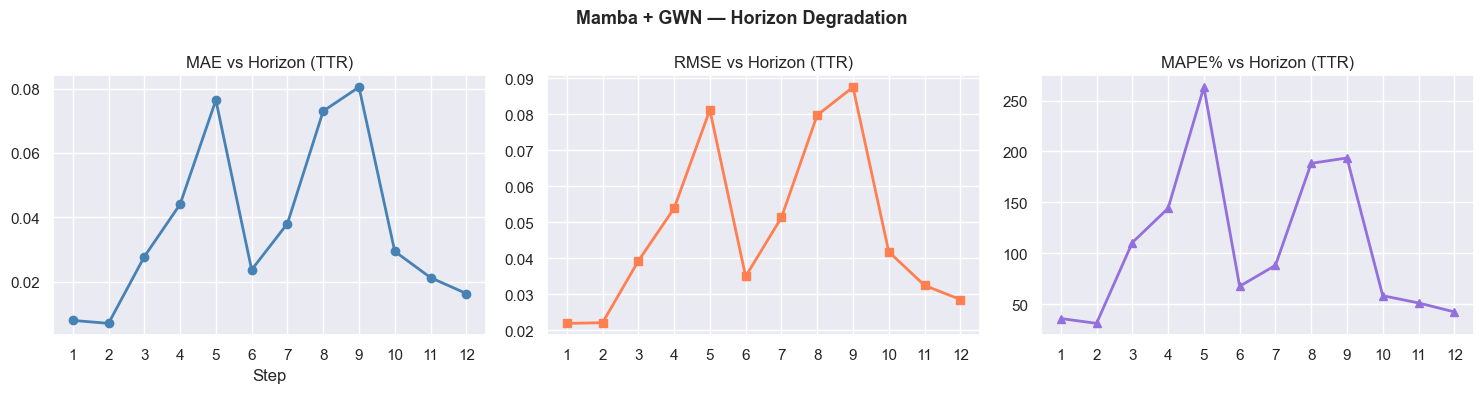

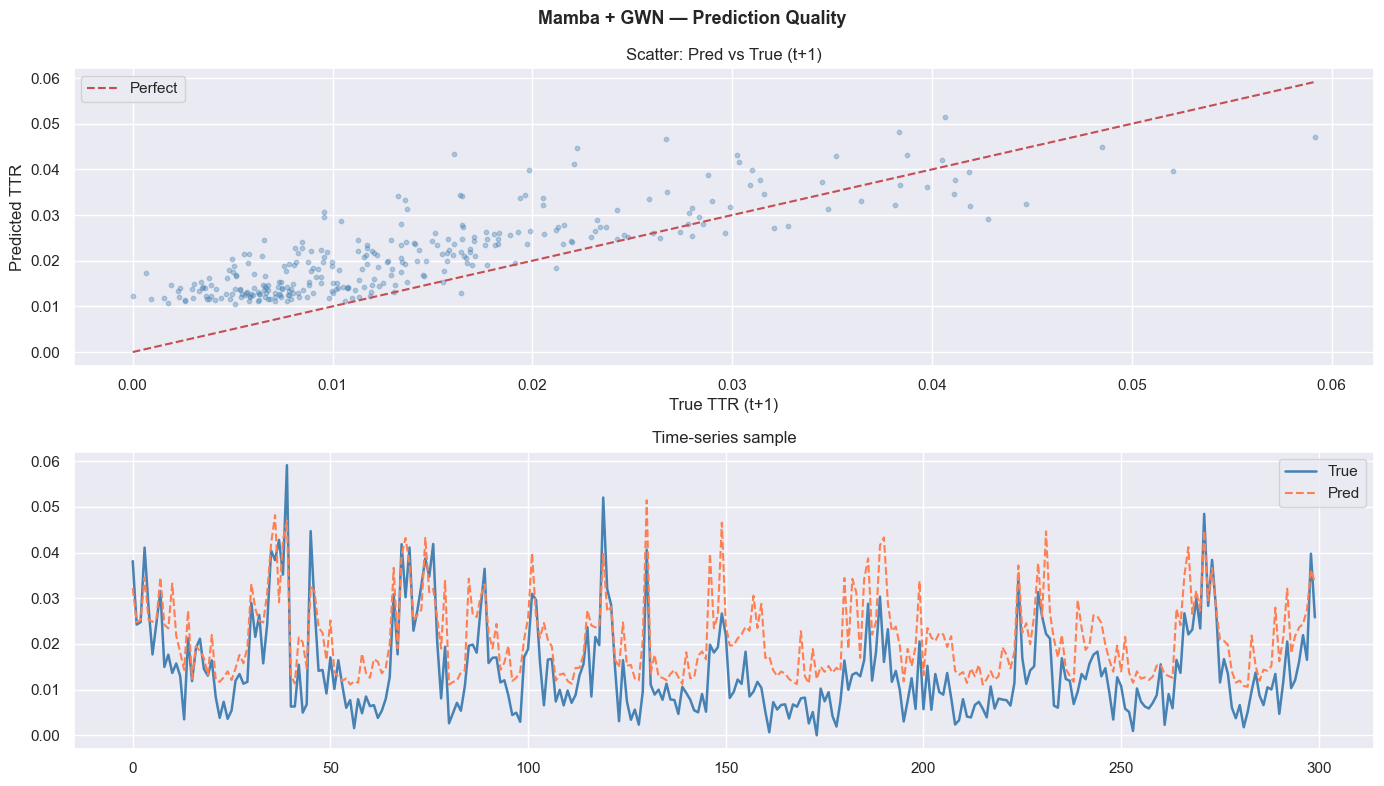

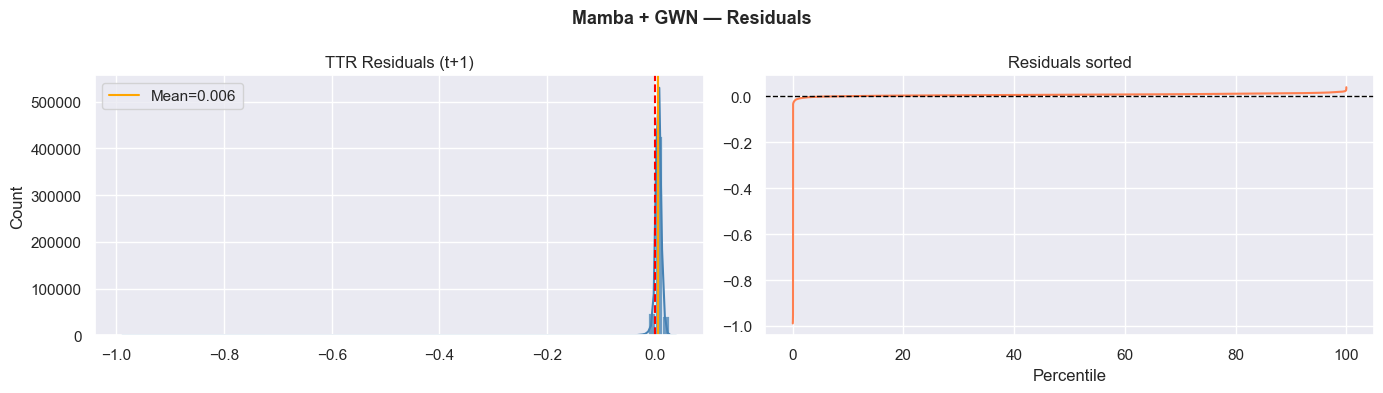

Residual mean=0.0063  std=0.0209  p5=-0.002  p95=0.015


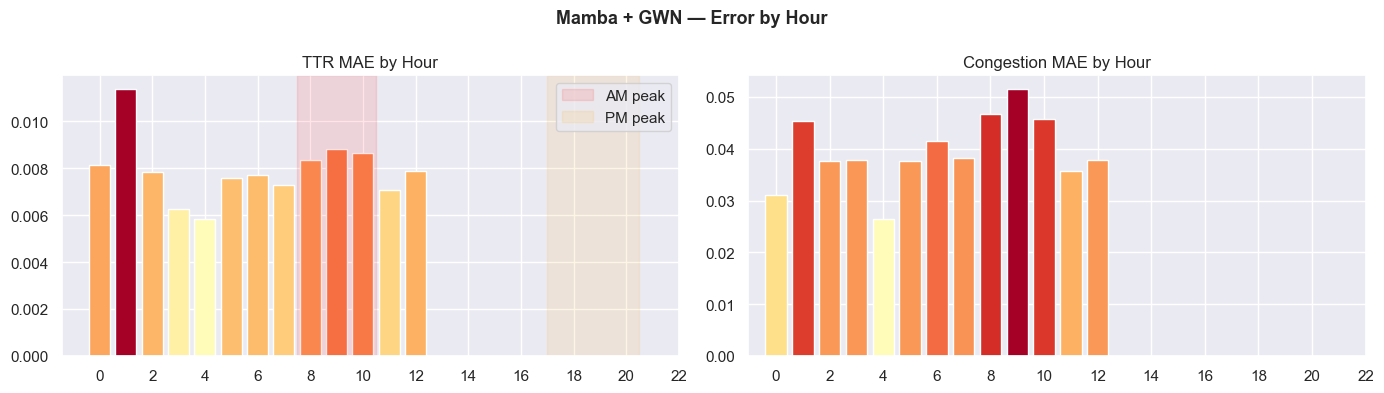

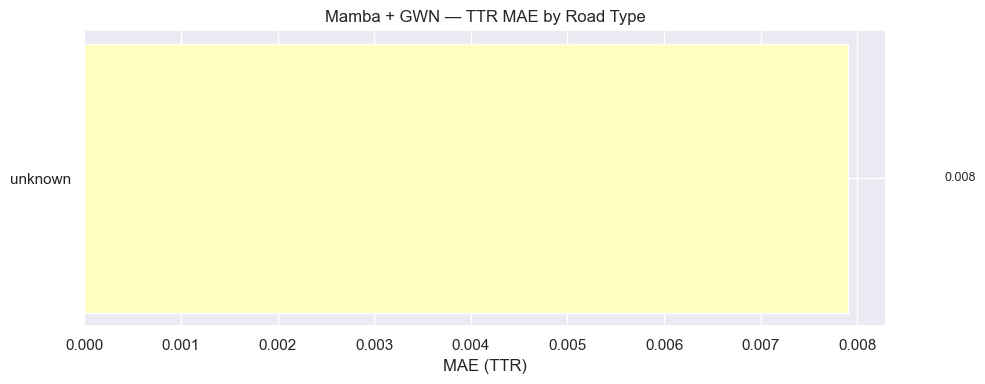

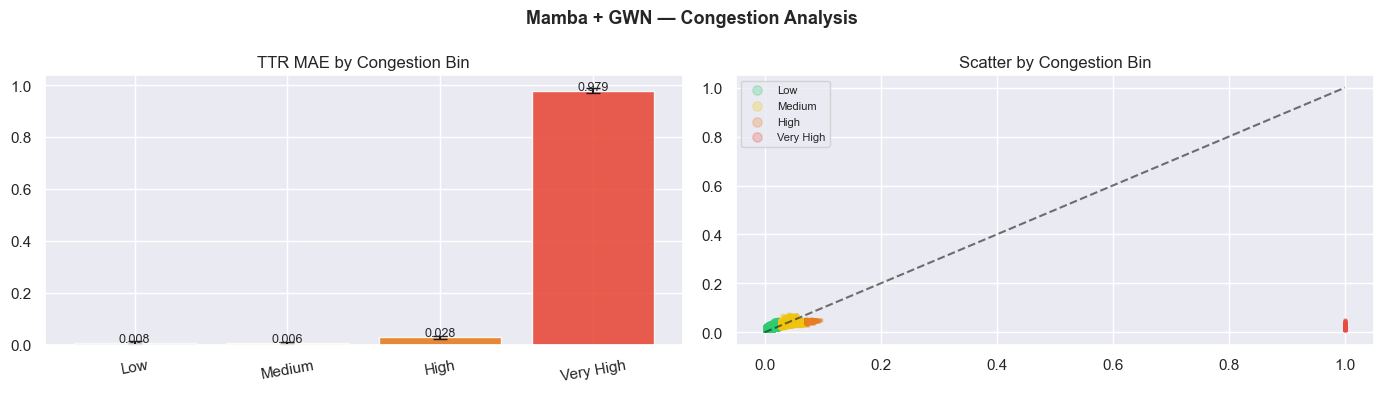

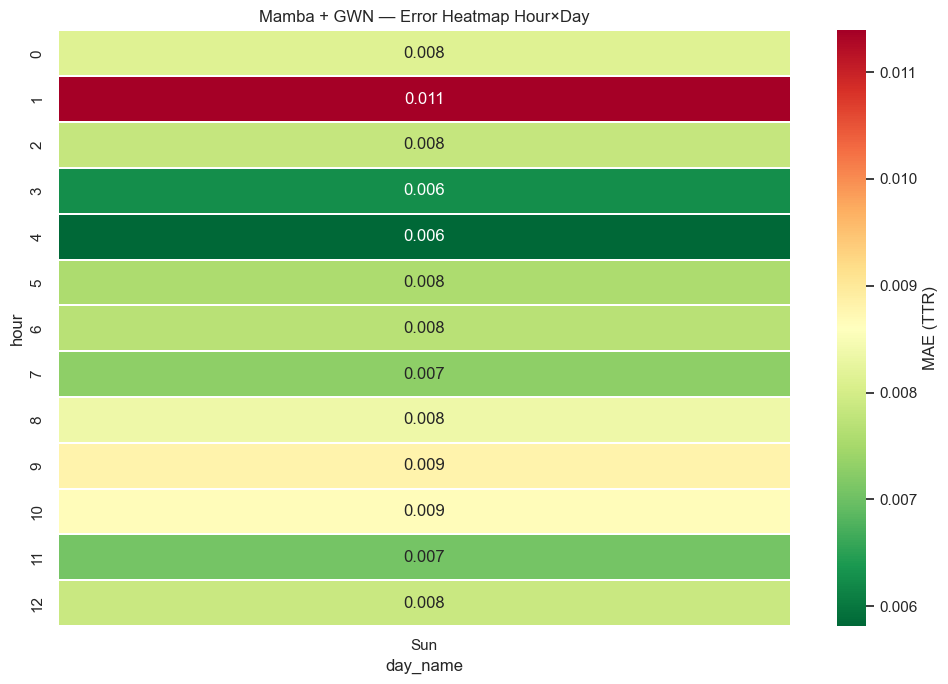

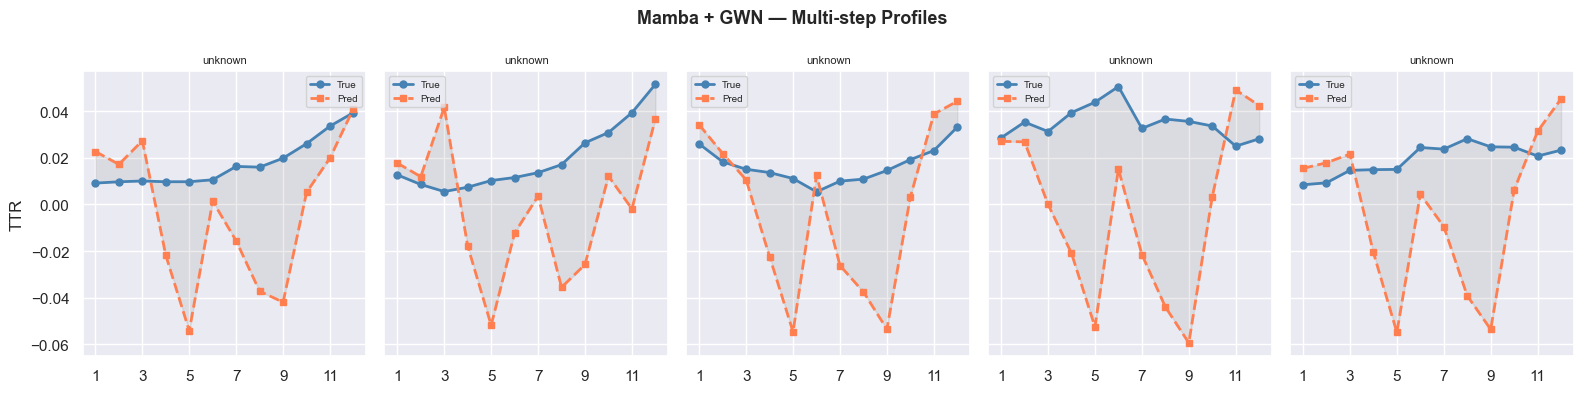


All 8 plots saved to models/mamba_gwn\eval_plots/


In [25]:

import warnings; warnings.filterwarnings('ignore')

# ── Plot 1: Horizon degradation ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps = range(1, H+1)
axes[0].plot(steps, mae_h,  'o-', color='steelblue', lw=2, ms=6)
axes[0].set_title('MAE vs Horizon (TTR)'); axes[0].set_xlabel('Step'); axes[0].set_xticks(steps)
axes[1].plot(steps, rmse_h, 's-', color='coral',     lw=2, ms=6)
axes[1].set_title('RMSE vs Horizon (TTR)'); axes[1].set_xticks(steps)
axes[2].plot(steps, mape_h, '^-', color='mediumpurple', lw=2, ms=6)
axes[2].set_title('MAPE% vs Horizon (TTR)'); axes[2].set_xticks(steps)
plt.suptitle(f'{MODEL_NAME} — Horizon Degradation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{PLOT_DIR}/horizon_degradation.png', dpi=120); plt.show()

# ── Plot 2: Pred vs Truth ─────────────────────────────────────────────────────
idx_s = np.sort(np.random.choice(len(ttr_p), min(300, len(ttr_p)), replace=False))
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
lo = min(ttr_t[idx_s,0].min(), ttr_p[idx_s,0].min())
hi = max(ttr_t[idx_s,0].max(), ttr_p[idx_s,0].max())
axes[0].scatter(ttr_t[idx_s,0], ttr_p[idx_s,0], alpha=0.35, s=10, color='steelblue')
axes[0].plot([lo,hi],[lo,hi],'r--',lw=1.5, label='Perfect'); axes[0].legend()
axes[0].set_xlabel('True TTR (t+1)'); axes[0].set_ylabel('Predicted TTR')
axes[0].set_title('Scatter: Pred vs True (t+1)')
axes[1].plot(range(len(idx_s)), ttr_t[idx_s,0], label='True',  color='steelblue', lw=1.8)
axes[1].plot(range(len(idx_s)), ttr_p[idx_s,0], label='Pred',  color='coral', lw=1.5, ls='--')
axes[1].set_title('Time-series sample'); axes[1].legend()
plt.suptitle(f'{MODEL_NAME} — Prediction Quality', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{PLOT_DIR}/pred_vs_truth.png', dpi=120); plt.show()

# ── Plot 3: Residuals ─────────────────────────────────────────────────────────
res = (ttr_p[:,0] - ttr_t[:,0]).flatten()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(res, bins=80, kde=True, ax=axes[0], color='steelblue', alpha=0.75)
axes[0].axvline(0, color='red', ls='--', lw=1.5)
axes[0].axvline(res.mean(), color='orange', ls='-', lw=1.5, label=f'Mean={res.mean():.3f}')
axes[0].set_title('TTR Residuals (t+1)'); axes[0].legend()
q = np.linspace(0,100,len(res))
axes[1].plot(q, np.sort(res), color='coral', lw=1.5)
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].set_title('Residuals sorted'); axes[1].set_xlabel('Percentile')
plt.suptitle(f'{MODEL_NAME} — Residuals', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{PLOT_DIR}/residuals.png', dpi=120); plt.show()
print(f'Residual mean={res.mean():.4f}  std={res.std():.4f}  p5={np.percentile(res,5):.3f}  p95={np.percentile(res,95):.3f}')

# ── Plot 4: Error by Hour ─────────────────────────────────────────────────────
df_meta['abs_err_ttr']  = np.abs(ttr_p[:,0] - ttr_t[:,0])
df_meta['abs_err_cong'] = np.abs(cng_p[:,0] - cng_t[:,0])
hourly = df_meta.groupby('hour')[['abs_err_ttr','abs_err_cong']].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
c = plt.cm.RdYlGn_r(hourly['abs_err_ttr'] / hourly['abs_err_ttr'].max())
axes[0].bar(hourly['hour'], hourly['abs_err_ttr'], color=c)
axes[0].axvspan(7.5,10.5,alpha=0.1,color='red',label='AM peak')
axes[0].axvspan(17,20.5,alpha=0.1,color='orange',label='PM peak')
axes[0].set_title('TTR MAE by Hour'); axes[0].legend(); axes[0].set_xticks(range(0,24,2))
c2 = plt.cm.RdYlGn_r(hourly['abs_err_cong'] / hourly['abs_err_cong'].max())
axes[1].bar(hourly['hour'], hourly['abs_err_cong'], color=c2)
axes[1].set_title('Congestion MAE by Hour'); axes[1].set_xticks(range(0,24,2))
plt.suptitle(f'{MODEL_NAME} — Error by Hour', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{PLOT_DIR}/error_by_hour.png', dpi=120); plt.show()

# ── Plot 5: Error by Road Type ────────────────────────────────────────────────
rt_err = df_meta.groupby('road_type')['abs_err_ttr'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(rt_err.index, rt_err.values, color=sns.color_palette('RdYlGn_r', len(rt_err)))
ax.set_xlabel('MAE (TTR)'); ax.set_title(f'{MODEL_NAME} — TTR MAE by Road Type')
for i,(v,rt) in enumerate(zip(rt_err.values,rt_err.index)):
    ax.text(v+0.001,i,f'{v:.3f}',va='center',fontsize=9)
plt.tight_layout(); plt.savefig(f'{PLOT_DIR}/error_by_road_type.png', dpi=120); plt.show()

# ── Plot 6: Error by Congestion Bin ──────────────────────────────────────────
df_meta['cong_bin'] = pd.cut(df_meta['true_cong'],
    bins=[0,0.2,0.4,0.65,1.0], labels=['Low','Medium','High','Very High'])
cbin = df_meta.groupby('cong_bin', observed=True)['abs_err_ttr'].agg(['mean','std'])
fig, axes = plt.subplots(1,2,figsize=(14,4))
colors=['#2ecc71','#f1c40f','#e67e22','#e74c3c']
bars=axes[0].bar(cbin.index,cbin['mean'],yerr=cbin['std'],capsize=5,color=colors,alpha=0.9)
axes[0].set_title('TTR MAE by Congestion Bin'); axes[0].tick_params(axis='x',rotation=10)
for b,v in zip(bars,cbin['mean']): axes[0].text(b.get_x()+b.get_width()/2,v+0.003,f'{v:.3f}',ha='center',fontsize=9)
for cb,col in zip(cbin.index,colors):
    m=df_meta['cong_bin']==cb
    axes[1].scatter(ttr_t[m,0],ttr_p[m,0],s=5,alpha=0.25,color=col,label=str(cb))
lo=min(ttr_t[:,0].min(),ttr_p[:,0].min()); hi=max(ttr_t[:,0].max(),ttr_p[:,0].max())
axes[1].plot([lo,hi],[lo,hi],'k--',lw=1.5,alpha=0.6); axes[1].legend(fontsize=8,markerscale=3)
axes[1].set_title('Scatter by Congestion Bin')
plt.suptitle(f'{MODEL_NAME} — Congestion Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{PLOT_DIR}/error_by_congestion.png', dpi=120); plt.show()

# ── Plot 7: Hour×Day Heatmap ──────────────────────────────────────────────────
day_map={0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df_meta['day_name']=df_meta['dayofweek'].map(day_map)
pivot=df_meta[df_meta['hour']>=0].pivot_table(values='abs_err_ttr',index='hour',columns='day_name',aggfunc='mean')
dord=[d for d in ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'] if d in pivot.columns]
fig,ax=plt.subplots(figsize=(10,7))
sns.heatmap(pivot[dord],cmap='RdYlGn_r',annot=True,fmt='.3f',linewidths=0.3,ax=ax,
            cbar_kws={'label':'MAE (TTR)'})
ax.set_title(f'{MODEL_NAME} — Error Heatmap Hour×Day')
plt.tight_layout(); plt.savefig(f'{PLOT_DIR}/error_heatmap.png', dpi=120); plt.show()

# ── Plot 8: Multi-step profile ────────────────────────────────────────────────
sidx=np.random.choice(len(ttr_p),5,replace=False)
fig,axes=plt.subplots(1,5,figsize=(16,4),sharey=True)
for ax,si in zip(axes,sidx):
    st=range(1,H+1)
    ax.plot(st,ttr_t[si],'o-',color='steelblue',lw=2,ms=5,label='True')
    ax.plot(st,ttr_p[si],'s--',color='coral',lw=2,ms=5,label='Pred')
    ax.fill_between(st,ttr_t[si],ttr_p[si],alpha=0.15,color='gray')
    rt=df_meta.iloc[si]['road_type'] if si<len(df_meta) else '?'
    ax.set_title(f'{rt}',fontsize=8); ax.set_xticks(range(1,H+1,2)); ax.legend(fontsize=7)
axes[0].set_ylabel('TTR')
plt.suptitle(f'{MODEL_NAME} — Multi-step Profiles',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{PLOT_DIR}/multistep_profile.png', dpi=120); plt.show()

print(f'\nAll 8 plots saved to {PLOT_DIR}/')


In [26]:

print("="*60)
print(f"  FINAL SUMMARY — {MODEL_NAME}")
print("="*60)
print(f"  Checkpoint : {CKPT_PATH}")
print(f"  Best epoch : {ckpt['epoch']}    Val loss : {ckpt['val_loss']:.4f}")
print()
print(f"  TRAVEL TIME RATIO")
print(f"    MAE  : {mae(ttr_p, ttr_t):.4f}")
print(f"    RMSE : {rmse(ttr_p, ttr_t):.4f}")
print(f"    MAPE : {mape(ttr_p, ttr_t):.2f}%")
print(f"    Bias : {float(np.mean(ttr_p - ttr_t)):+.4f}  (+ = over-predicting)")
print()
print(f"  CONGESTION LEVEL")
print(f"    MAE  : {mae(cng_p, cng_t):.4f}")
print(f"    RMSE : {rmse(cng_p, cng_t):.4f}")
print()
print(f"  Worst hour     : {int(hourly.loc[hourly['abs_err_ttr'].idxmax(),'hour'])}:00")
print(f"  Best  hour     : {int(hourly.loc[hourly['abs_err_ttr'].idxmin(),'hour'])}:00")
print(f"  Worst road type: {rt_err.index[0]}  (MAE={rt_err.iloc[0]:.4f})")
print(f"  Best  road type: {rt_err.index[-1]}  (MAE={rt_err.iloc[-1]:.4f})")
print("="*60)

  FINAL SUMMARY — Mamba + GWN
  Checkpoint : models/mamba_gwn/best.pt
  Best epoch : 21    Val loss : 0.0043

  TRAVEL TIME RATIO
    MAE  : 0.0371
    RMSE : 0.0528
    MAPE : 106.34%
    Bias : -0.0295  (+ = over-predicting)

  CONGESTION LEVEL
    MAE  : 0.1517
    RMSE : 0.1877

  Worst hour     : 1:00
  Best  hour     : 4:00
  Worst road type: unknown  (MAE=0.0079)
  Best  road type: unknown  (MAE=0.0079)
